# Ejercicio 1 Practico 2 Ciencia de Datos

In [17]:
from wget import download
from os import path, listdir
import pandas as pd
import sweetviz as sv
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [13]:
if not path.exists("ObesityDataSet_raw_and_data_sinthetic.txt"):
  download("https://ignaciorlando.github.io/datasets/data-science/ObesityDataSet_raw_and_data_sinthetic.txt")
else:
  print("Ya existe el archivo.")

if not path.exists("ObesityDataSet_raw_and_data_sinthetic.csv"):
  download("https://ignaciorlando.github.io/datasets/data-science/ObesityDataSet_raw_and_data_sinthetic.csv")
else:
  print("Ya existe el archivo.")

Ya existe el archivo.
Ya existe el archivo.


In [14]:
lista_archivos = listdir("./")
print(f"El contenido de la carpeta es: {lista_archivos}")
print("")

# ii) leer el archivo de descripcion y mostrar su contenido
with open("ObesityDataSet_raw_and_data_sinthetic.txt", "r", encoding="utf-8") as archivo_texto:
    print(archivo_texto.read())

El contenido de la carpeta es: ['ejercicio1.ipynb', 'ejercicio2.ipynb', 'ejercicio3.ipynb', 'ObesityDataSet_raw_and_data_sinthetic.csv', 'ObesityDataSet_raw_and_data_sinthetic.txt', 'practico3-env', 'requeriments']

Obesidad

La obesidad, que causa problemas físicos y mentales, es un problema de salud global con graves consecuencias. La prevalencia de la obesidad aumenta constantemente, por lo que se necesita nueva investigación que examine los factores que influyen en la obesidad y cómo predecir la aparición de la condición según estos factores.

Los datos fueron recolectados como parte de este trabajo científico: https://www.sciencedirect.com/science/article/pii/S2352340919306985#sec1

Información del Conjunto de Datos

Este conjunto de datos incluye información para la estimación de los niveles de obesidad en individuos de los países de México, Perú y Colombia, en función de sus hábitos alimenticios y condición física. Los datos contienen 17 atributos y 2111 registros, los registros

In [18]:
# iii) Leer el archivo de datos
obesity_dataset = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

# iv) Imprimir la cabecera del archivo (nombres de columnas)
print(obesity_dataset.columns)

# v) Imprimir los primeros 5 registros
obesity_dataset.head()

Index(['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP',
       'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE',
       'CAEC', 'MTRANS', 'NObeyesdad'],
      dtype='str')


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [11]:
# vi) Imprimir el resumen estadístico
obesity_dataset.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


#### 1.a)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)



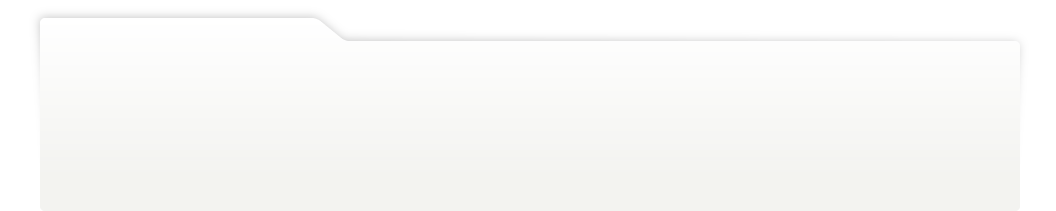
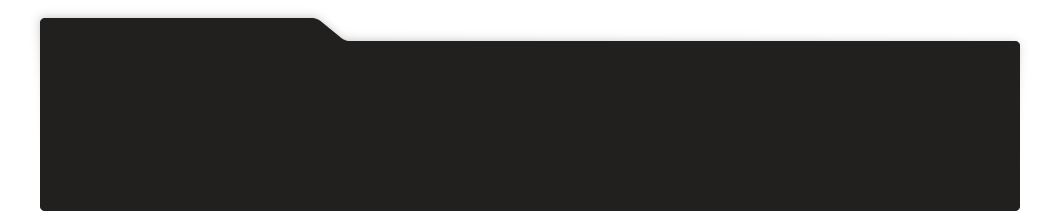
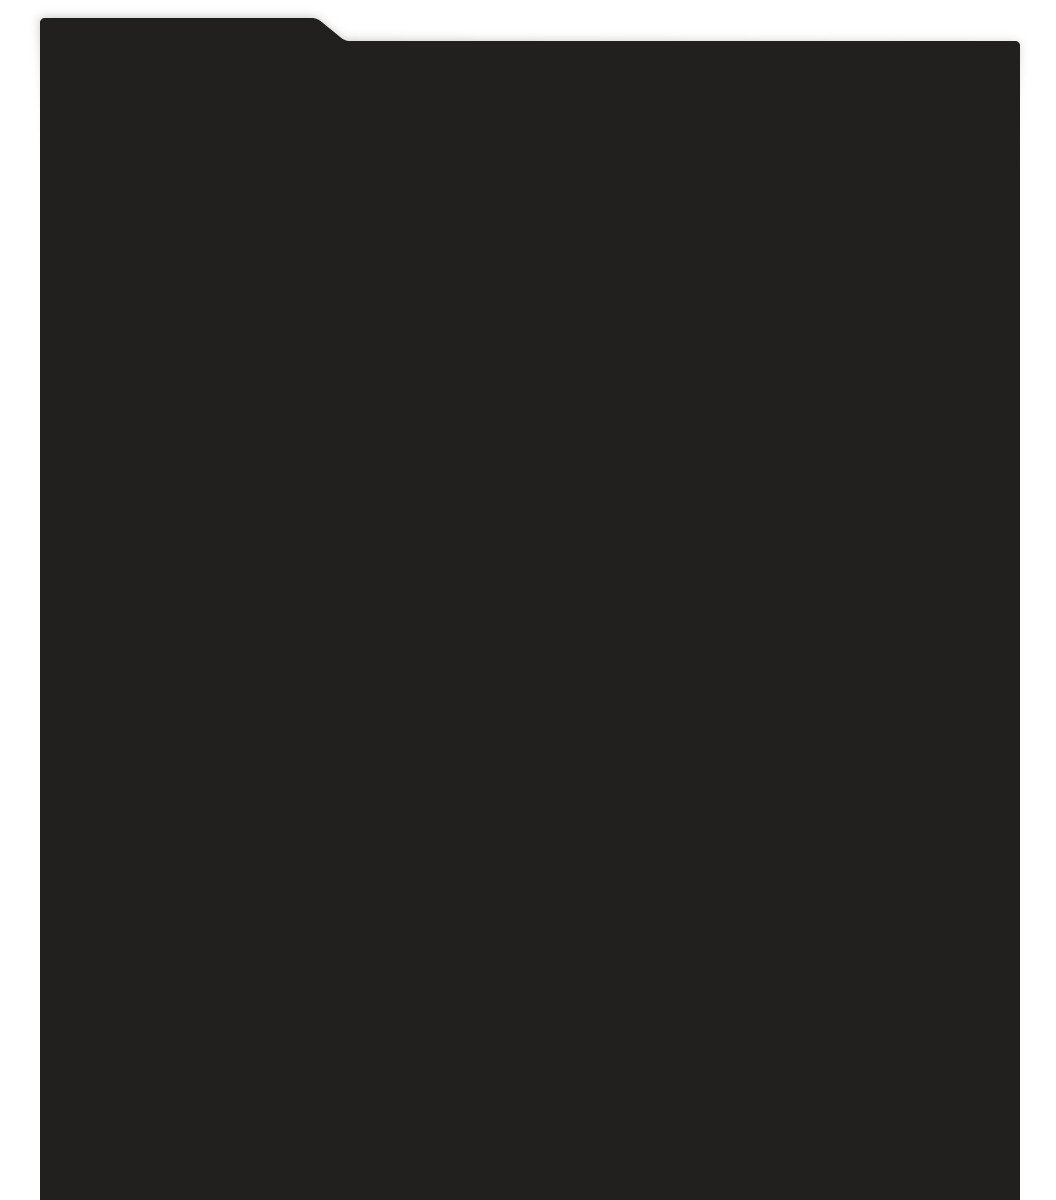
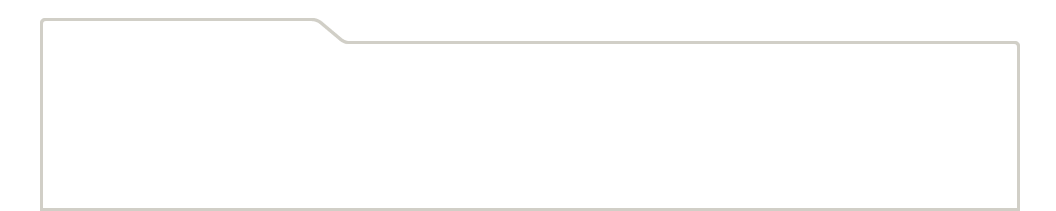
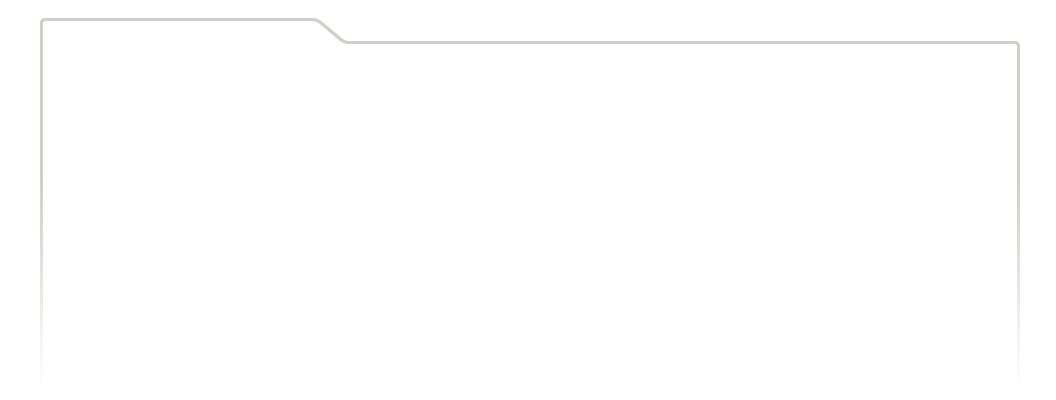
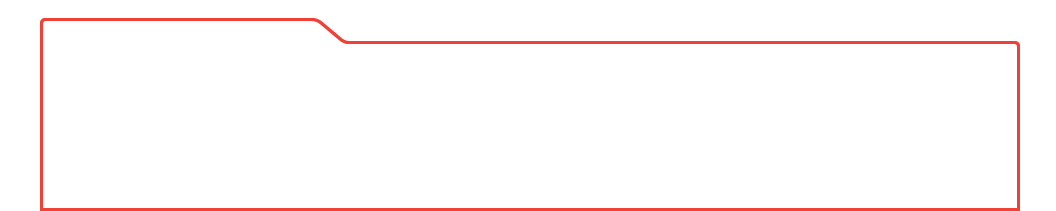
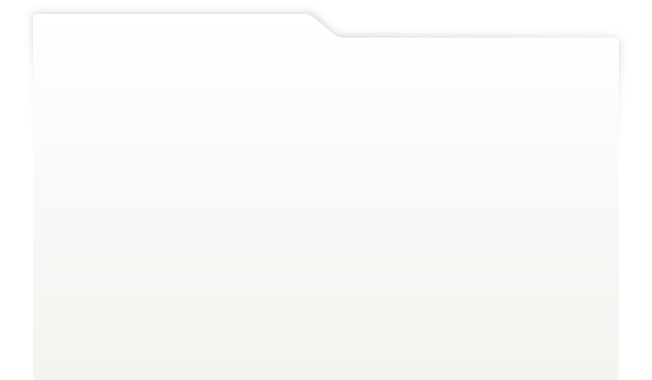
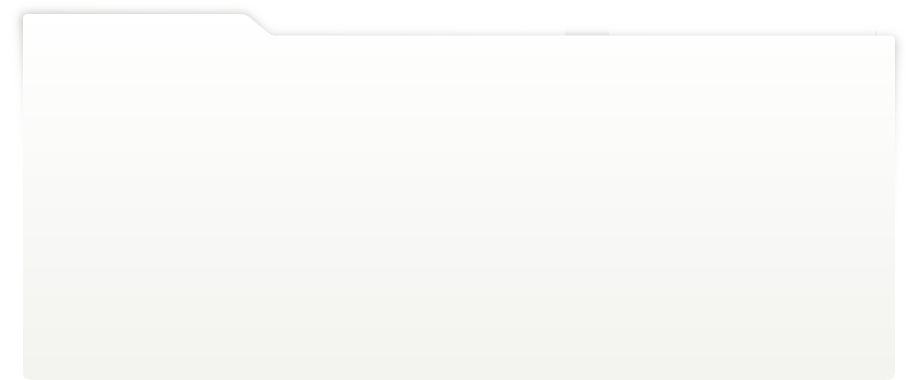
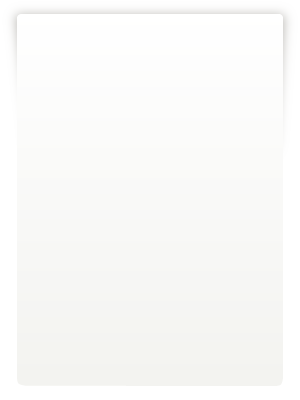
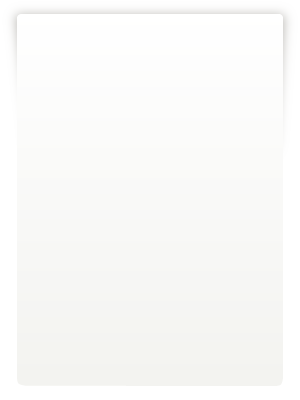
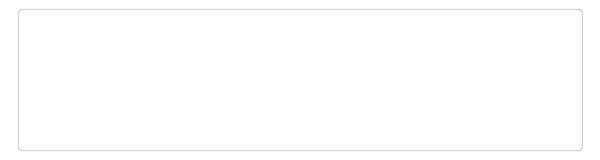
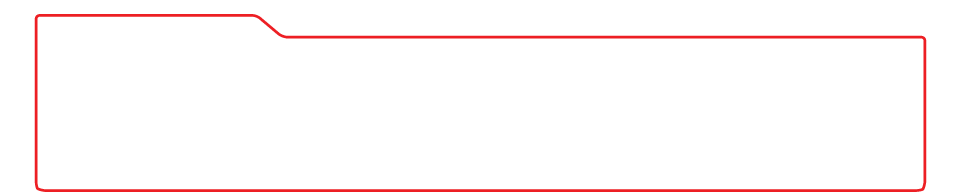
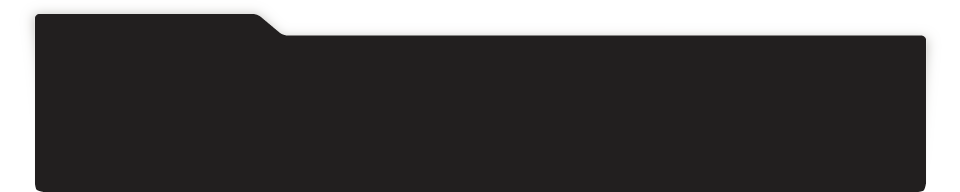
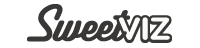
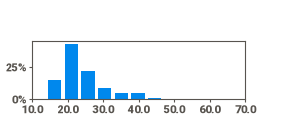
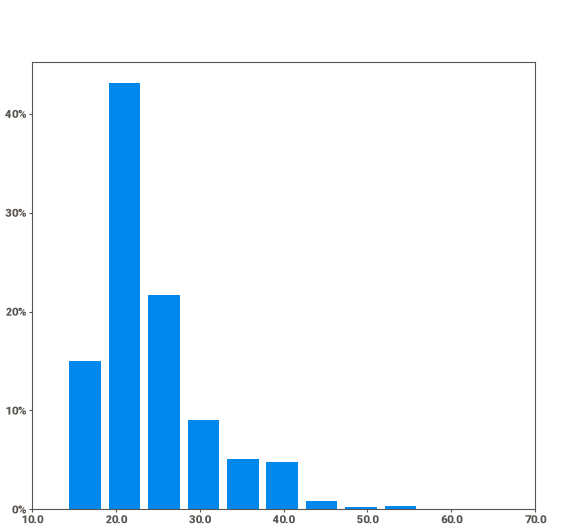
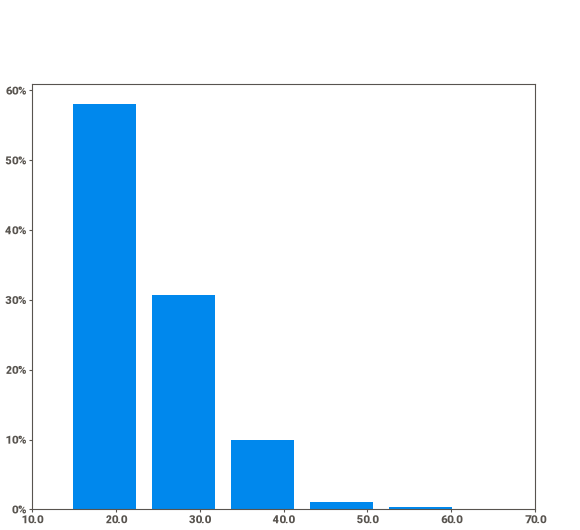
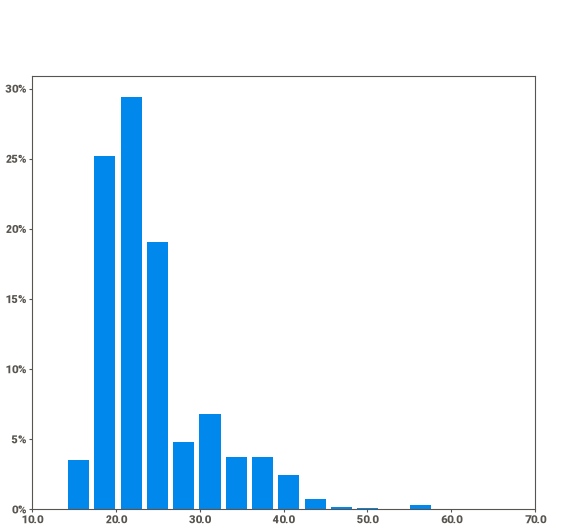
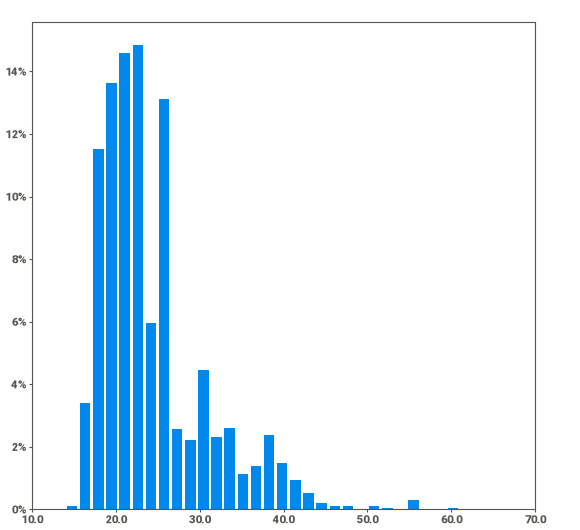
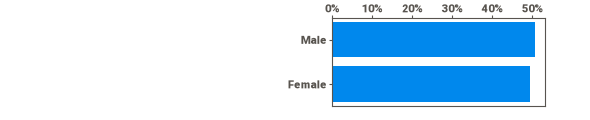
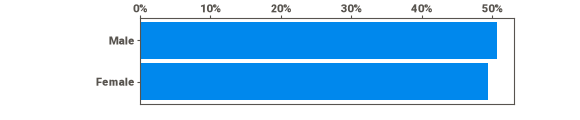
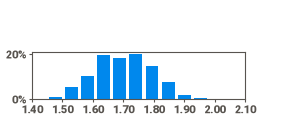
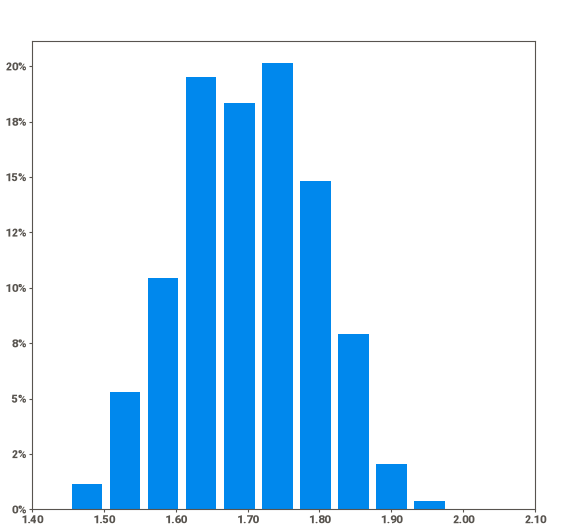
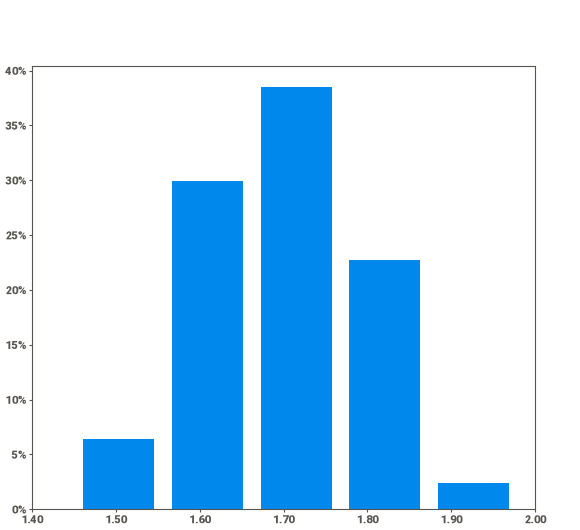
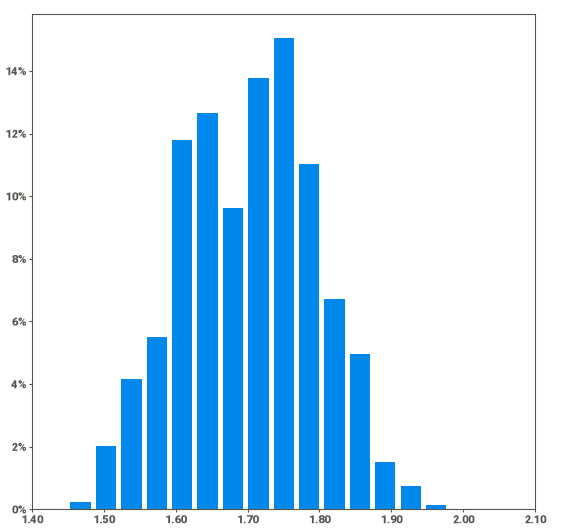
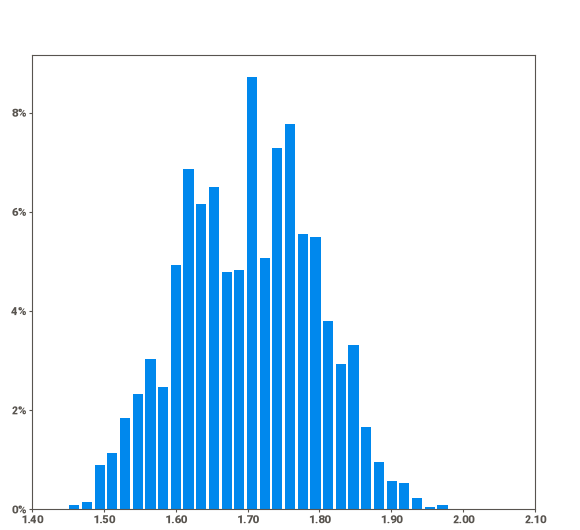
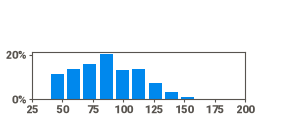
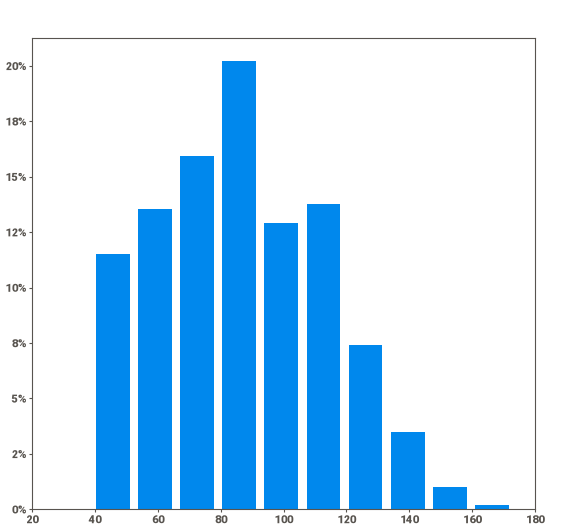
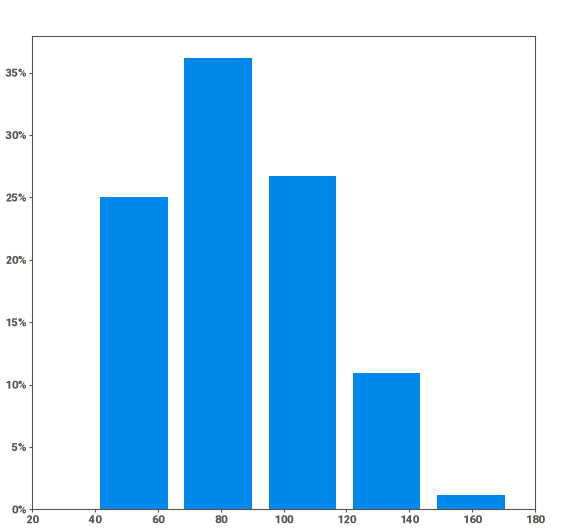
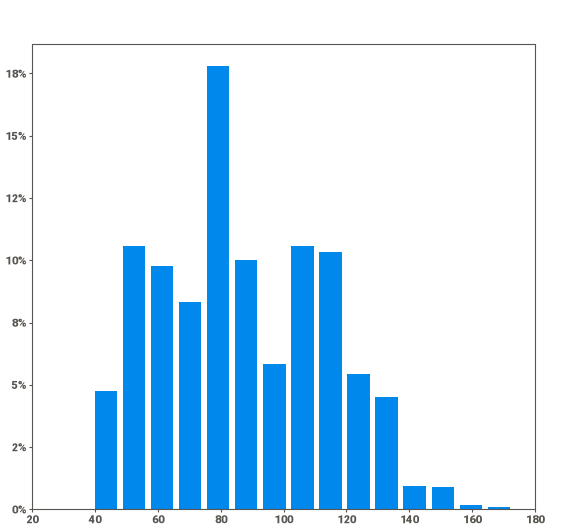
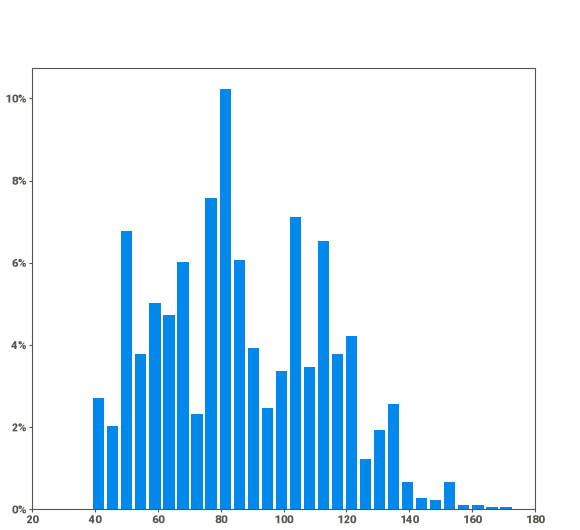
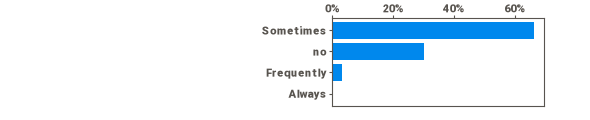
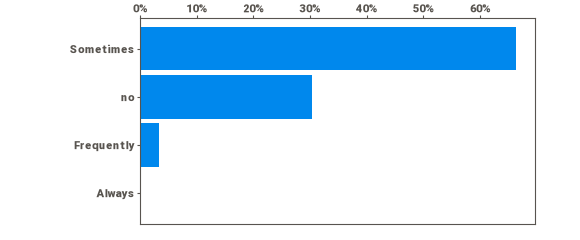
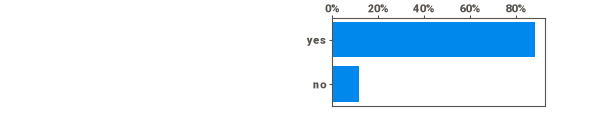
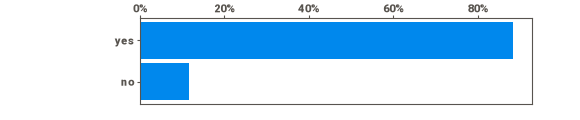
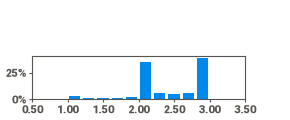
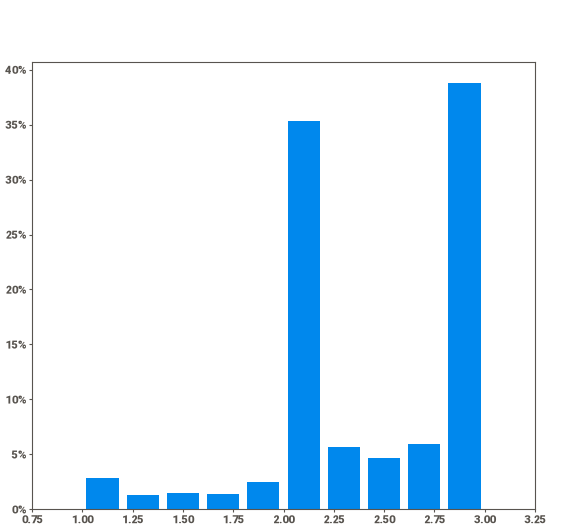
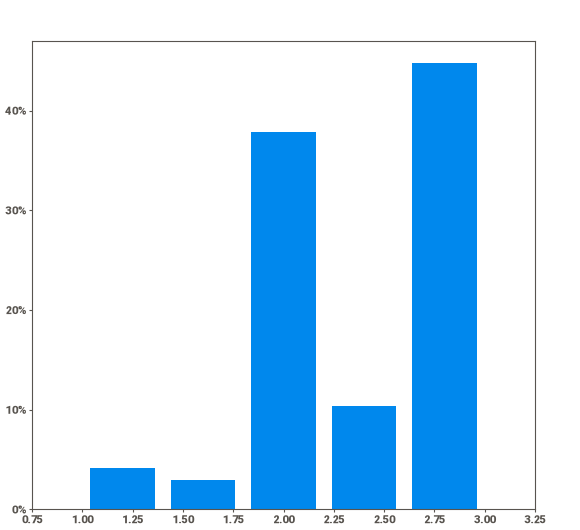
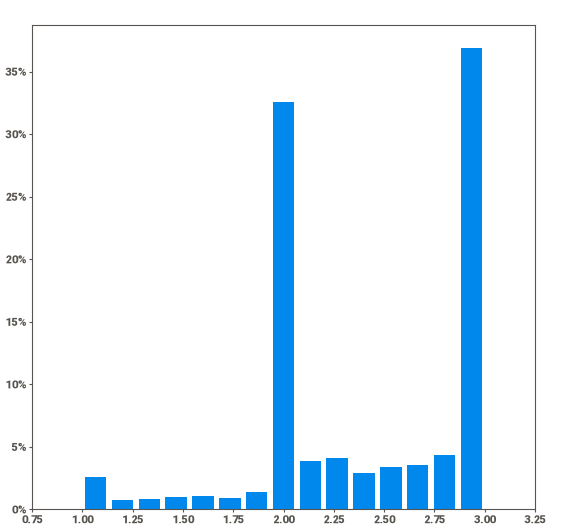
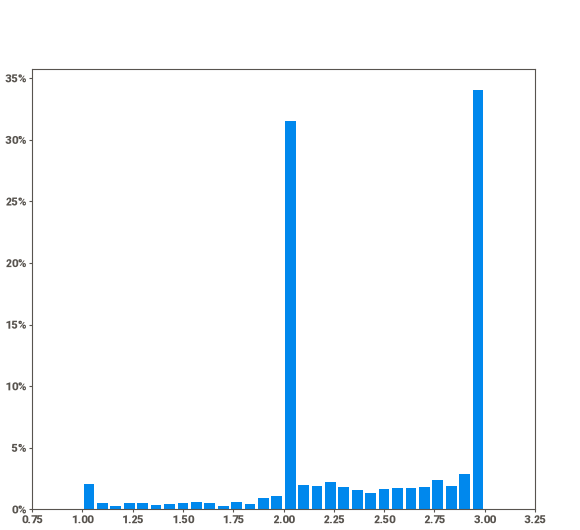
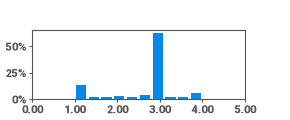
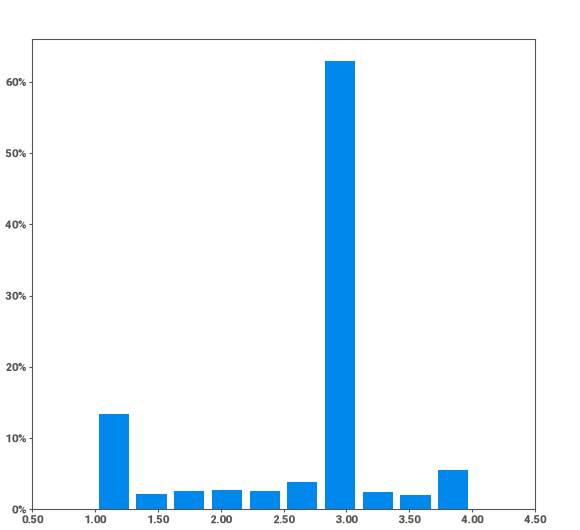
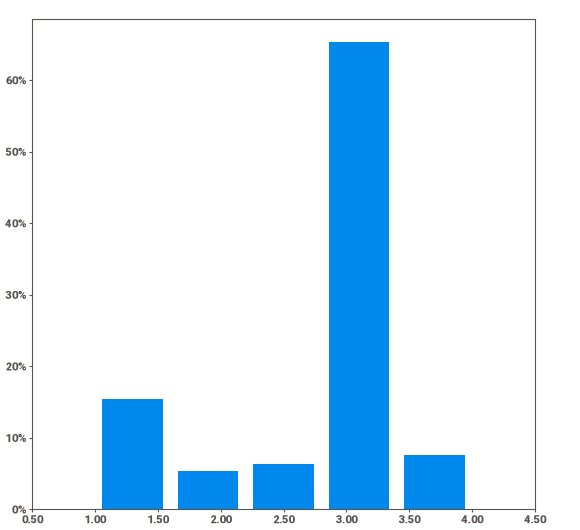
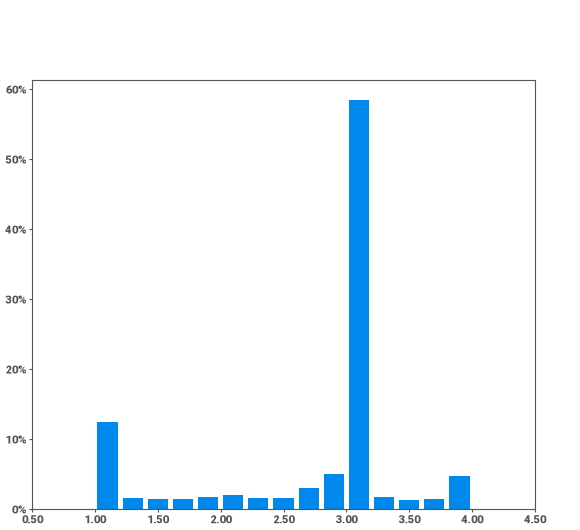
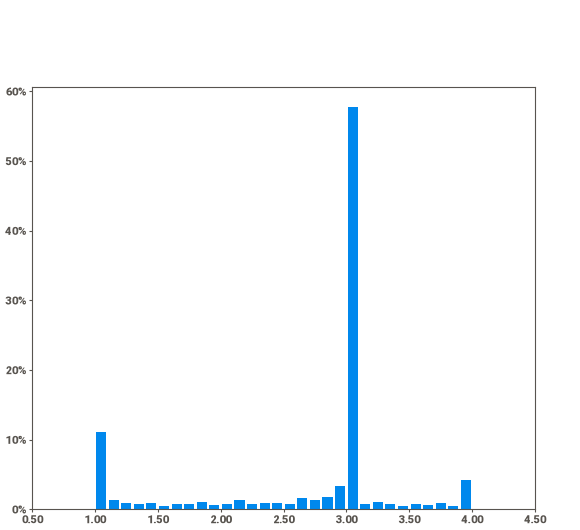
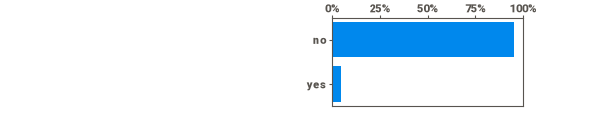
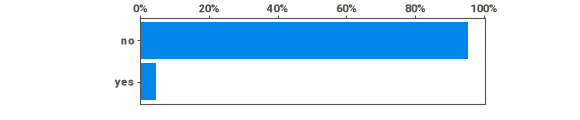
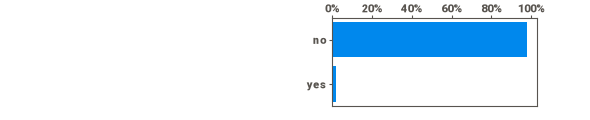
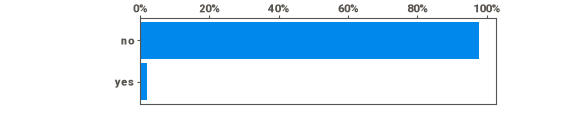
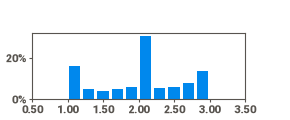
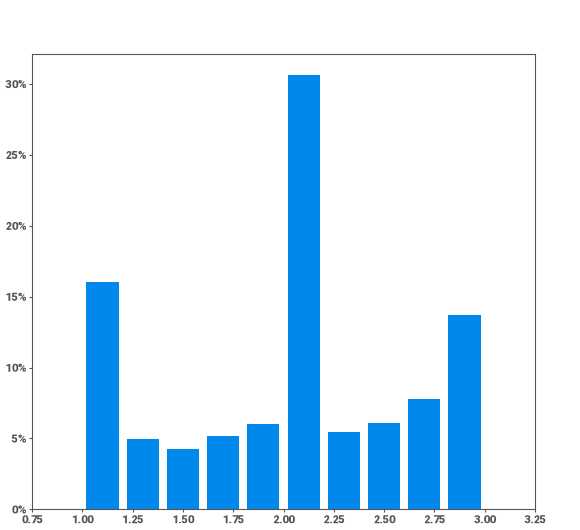
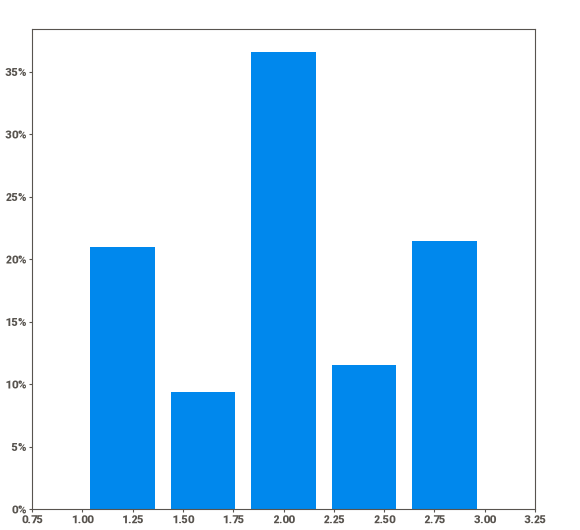
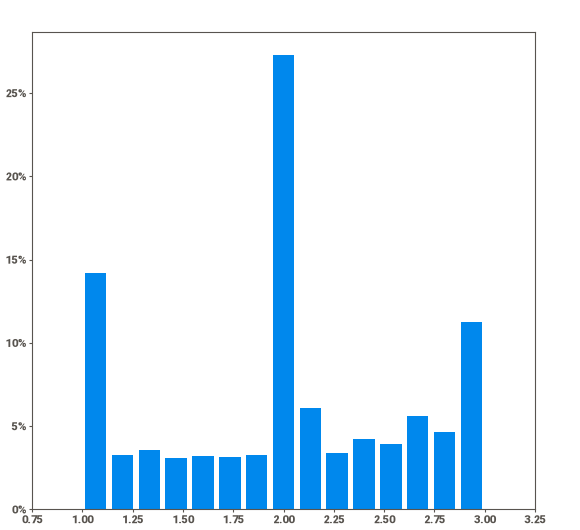
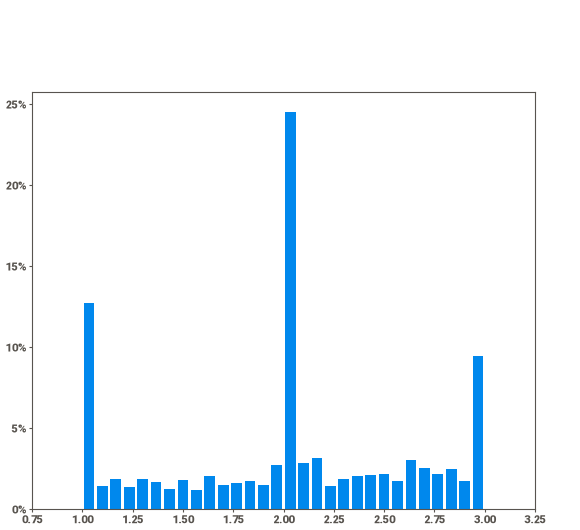
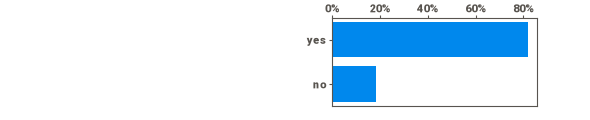
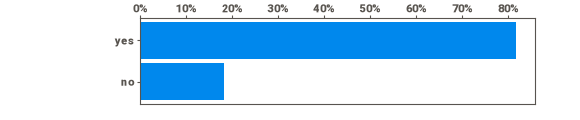
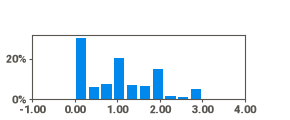
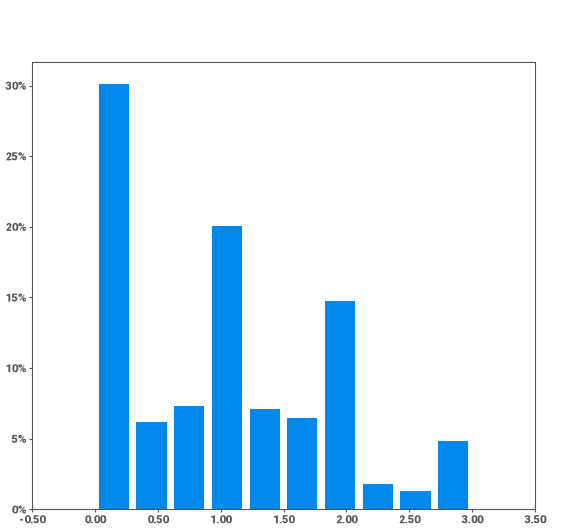
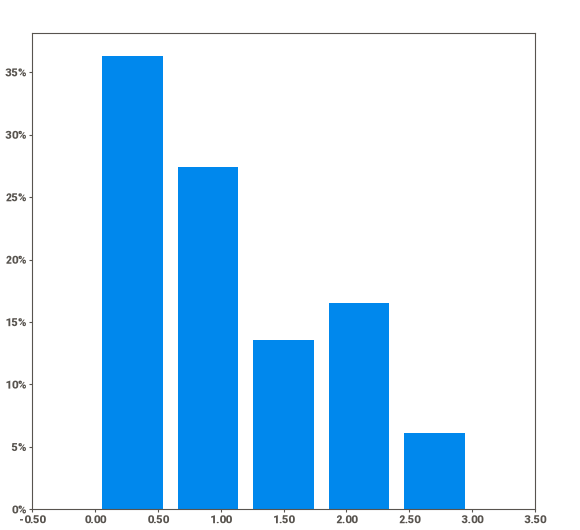
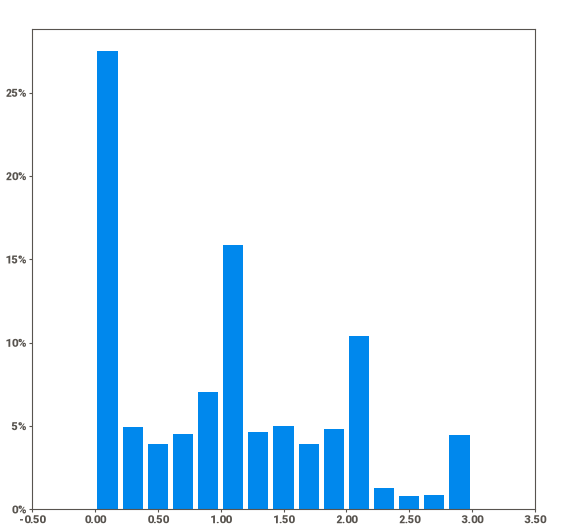
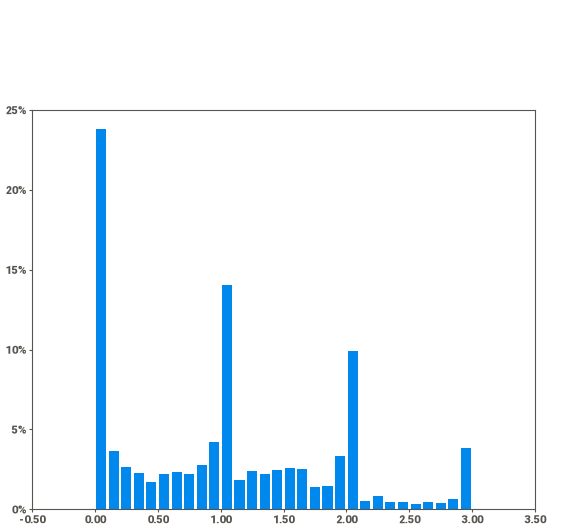
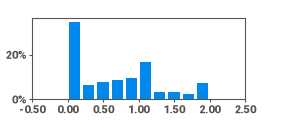
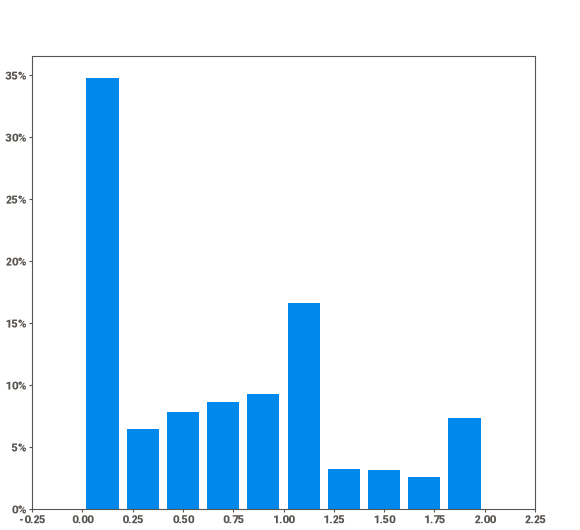
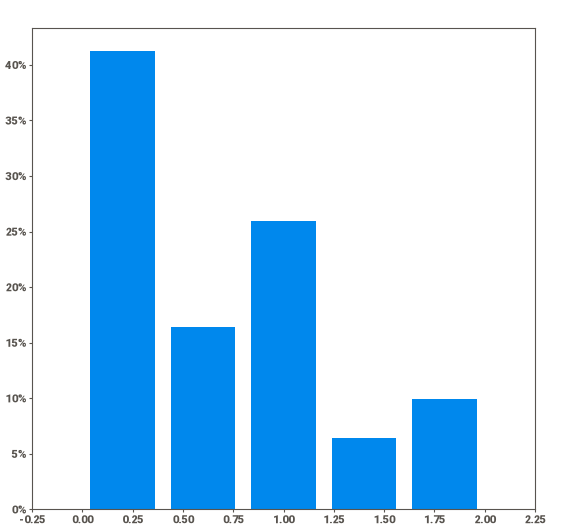
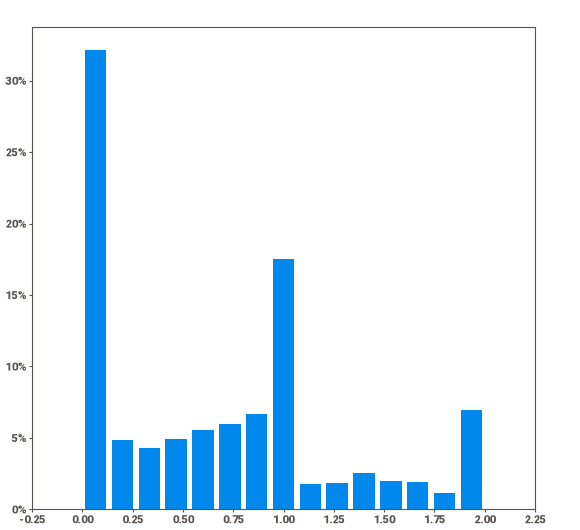
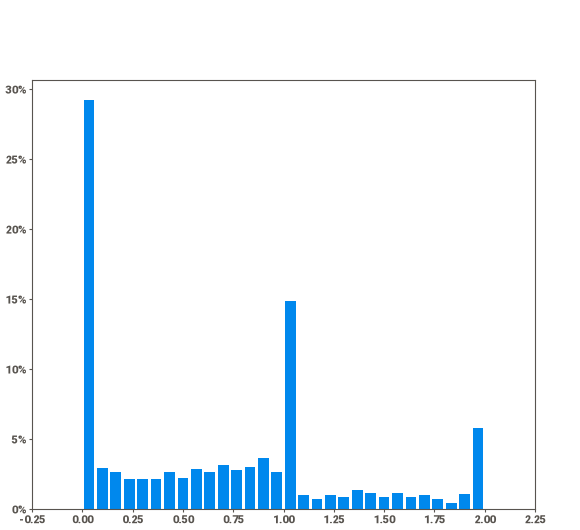
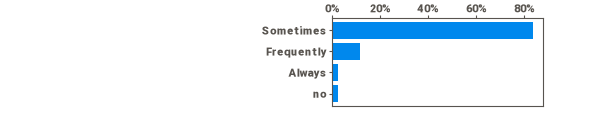
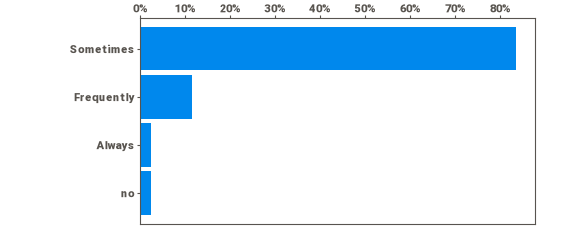
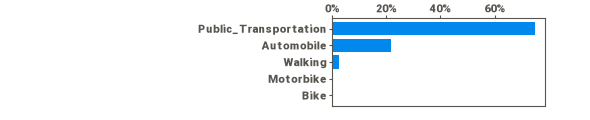
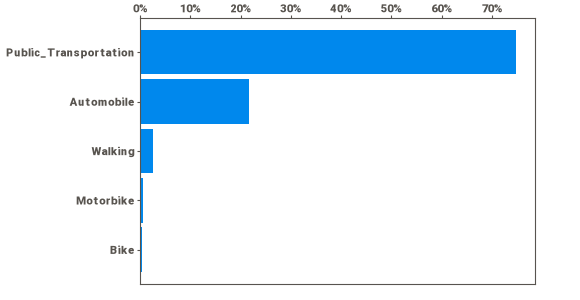
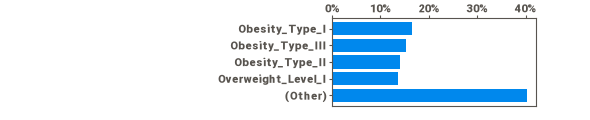
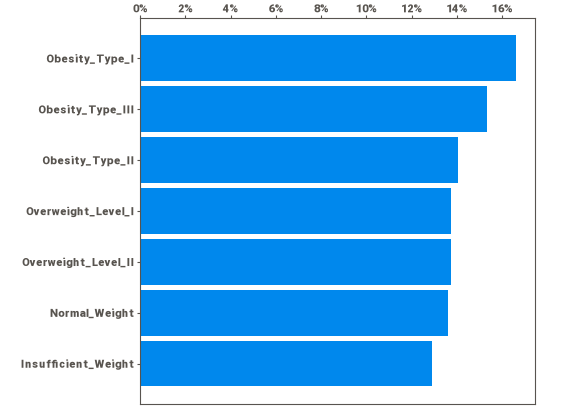
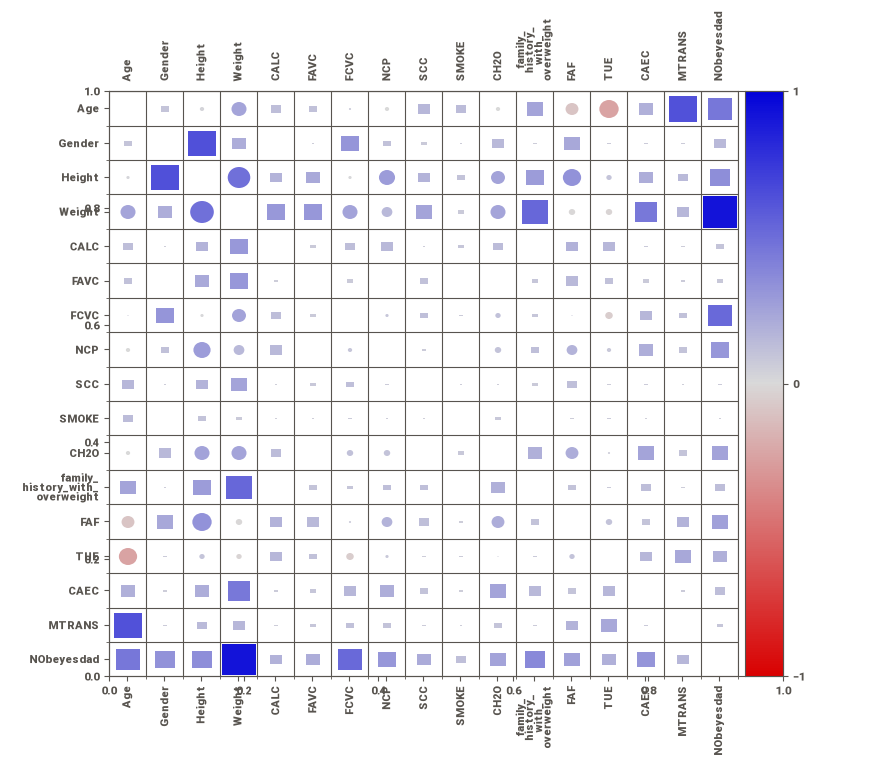
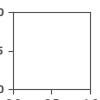

In [11]:
report = sv.analyze(obesity_dataset)
report .show_notebook()

#### Relación con describe() del TP2: 
En el práctico anterior, al ejecutar describe(), obteníamos métricas numéricas puntuales (como mean, std, 50%, min y max) solo para las columnas numéricas como Age, Height, Weight, FAF, TUE, etc.  

#### Aporte del ProfileReport: 
Al abrir el archivo ObesityDataSet_report.html, los histogramas permiten visualizar gráficamente la forma de estas distribuciones. Por ejemplo, en la variable Age (Edad) el histograma muestra una clara concentración hacia la izquierda con una "cola" a la derecha. Esto explica por qué en describe() la media ($24.31$) es mayor que la mediana ($22.77$). En FAF (actividad física) o TUE (uso de tecnología), se observan picos pronunciados en valores enteros ($0$, $1$, $2$), mostrando que muchos datos provienen de respuestas discretas o fueron sintetizados en rangos específicos. A diferencia de describe() (que omitía el texto por defecto), el reporte incluye la distribución de variables cualitativas como NObeyesdad, Gender o MTRANS, mostrando la frecuencia de cada categoría mediante gráficos de barras.  

#### 1.b)
Hipótesis 1: A mayor actividad física (FAF), menor peso corporal (Weight).

Hipótesis 2: A mayor edad (Age), mayor peso corporal (Weight).

Hipótesis 3: A mayor tiempo de uso de tecnología (TUE), menor frecuencia de actividad física (FAF).

#### 1.c)

Correlación 1 (FAF vs Weight): -0.0514


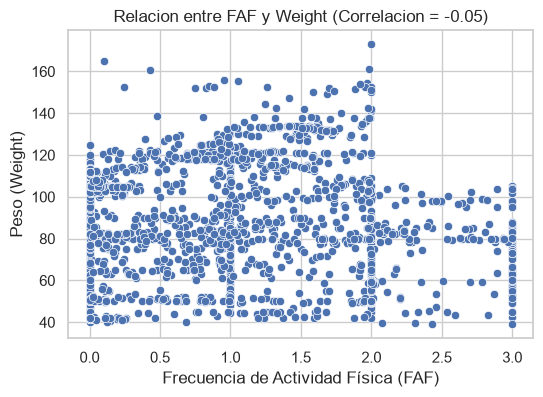

Correlación 2 (Age vs Weight): 0.2026


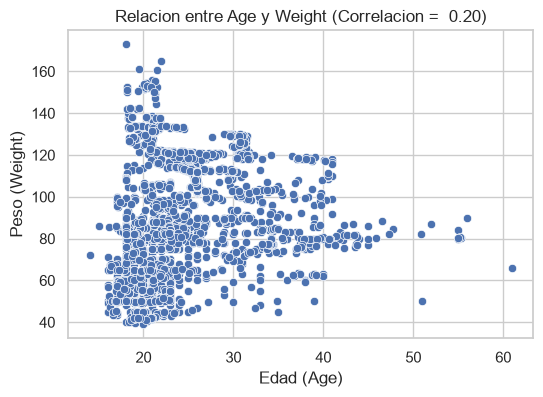

Correlación 3 (TUE vs FAF): 0.0586


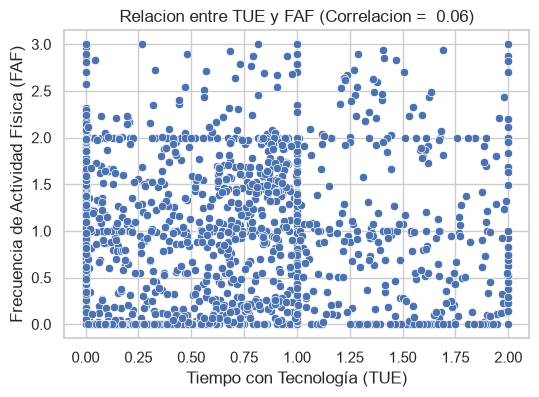

In [28]:
# --- Evaluación Hipótesis 1: FAF vs Weight ---
corr1 = obesity_dataset['FAF'].corr(obesity_dataset['Weight'])
print(f"Correlación 1 (FAF vs Weight): {corr1:.4f}")

plt.figure(figsize=(6, 4))
sns.scatterplot(data=obesity_dataset, x='FAF', y='Weight')
plt.title(f"Relacion entre FAF y Weight (Correlacion = {corr1:.2f})")
plt.xlabel("Frecuencia de Actividad Física (FAF)")
plt.ylabel("Peso (Weight)")
plt.show()

# --- Evaluación Hipótesis 2: Age vs Weight ---
corr2 = obesity_dataset['Age'].corr(obesity_dataset['Weight'])
print(f"Correlación 2 (Age vs Weight): {corr2:.4f}")

plt.figure(figsize=(6, 4))
sns.scatterplot(data=obesity_dataset, x='Age', y='Weight')
plt.title(f"Relacion entre Age y Weight (Correlacion =  {corr2:.2f})")
plt.xlabel("Edad (Age)")
plt.ylabel("Peso (Weight)")
plt.show()

# --- Evaluación Hipótesis 3: TUE vs FAF ---
corr3 = obesity_dataset['TUE'].corr(obesity_dataset['FAF'])
print(f"Correlación 3 (TUE vs FAF): {corr3:.4f}")

plt.figure(figsize=(6, 4))
sns.scatterplot(data=obesity_dataset, x='TUE', y='FAF')
plt.title(f"Relacion entre TUE y FAF (Correlacion =  {corr3:.2f})")
plt.xlabel("Tiempo con Tecnología (TUE)")
plt.ylabel("Frecuencia de Actividad Física (FAF)")
plt.show()

#### justificacion:
Hipótesis 1 ($FAF$ vs $Weight$): La correlación es débil o cercana a cero (alrededor de $-0.05$). En el gráfico no se observa una tendencia clara descendente, por lo que no es verosímil asumir una relación lineal directa entre la frecuencia de ejercicio y el peso de forma aislada sin considerar otras variables (como la altura o dieta).  

Hipótesis 2 ($Age$ vs $Weight$): Presenta una correlación positiva moderada/débil (alrededor de $0.21$). El gráfico de dispersión muestra cierta tendencia de crecimiento del peso en edades jóvenes, por lo que resulta parcialmente verosímil.  

Hipótesis 3 ($TUE$ vs $FAF$): Presenta una correlación negativa moderada (alrededor de $-0.18$). Muestra una leve tendencia de que quienes usan más tecnología realizan menos actividad física, resultando moderadamente verosímil. 